## Atlantis PAH PC injection from surface spill of diesel at Active Pass
Tug towing a fuel barge misjudges the tides in Active Pass and barge gets pushed on the rocks puncturing one of its fuel tanks, spilling 500 m<sup>-3</sup> of marine diesel. Scenario is built on ROC report 869, 2019.

In [1]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import itertools
from pathlib import Path
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import ssam_groups as groups
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
# Reading in Atlantis map
shapefile_name = "/ocean/rlovindeer/Atlantis/ssam_oceanparcels/SalishSea/SalishSea_July172019_2/SalishSea_July172019.shp"
data_df_original = gpd.read_file(shapefile_name)
data_df_original = data_df_original.sort_values(by=['BOX_ID'])
data_df = data_df_original.set_index('BOX_ID')
box_depth = data_df['BOTZ']
land_boxes = box_depth==0
land_boxes = data_df.index[land_boxes]
land_df = data_df.loc[land_boxes]
jdf_df = data_df.loc[data_df.Region=='Juan de Fuca']
hs_df = data_df.loc[data_df.Region=='Howe Sound']
strait_df = data_df.loc[data_df.Region=='Strait of Georgia']
ps_df = data_df.loc[data_df.Region=='Puget Sound']

### Define scenario and control files

In [3]:
hex_colour = '#863092'
hatches = ['oo', '///', 'xx', '++']

In [4]:
# Oil injection file 
oil_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/ForcingFiles/')
oil_paths = sorted([p for p in oil_root.glob('SSAM_Scenario_4a*-07-*_10000_WSFmean.nc')])
oil_files = [xr.open_dataset(oil_scen,decode_cf=True) for oil_scen in oil_paths]

In [5]:
# Read in salish sea atlantis output files.
scenario_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1')

control_file = "/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/Control/highres-control-3y-2019-2022/outputSalishSea.nc"
control = xr.open_dataset(str(control_file), decode_cf=True)
time = np.ma.filled(control.variables['t'])

In [6]:
scenario_paths = sorted([p for p in scenario_root.glob('highres-2019-2022_4a*/outputSalishSea.nc')])
for path in scenario_paths:
    print(path.parent.stem, groups.conditions[str(path.parent.stem).split(sep = '_')[3]])

highres-2019-2022_4a_1_2019-07-04 low Fraser spring tide
highres-2019-2022_4a_2_2019-07-10 low Fraser neap tide
highres-2019-2022_4a_3_2020-07-22 high Fraser spring tide
highres-2019-2022_4a_4_2020-07-12 high Fraser neap tide


In [7]:
scenario_datasets = [xr.open_dataset(scen,decode_cf=True) for scen in scenario_paths]

In [8]:
# start and end time of data display, after burn-in
start = 0
end = time.size-1

### Mapping spill extent

AP-FlTs BOX_ID
63    143948861
Name: AREA, dtype: int64
AP-FlTn BOX_ID
63    143948861
Name: AREA, dtype: int64
AP-FhTn BOX_ID
60    322474724
62    289555749
63    143948861
Name: AREA, dtype: int64
AP-FhTs BOX_ID
33    181216243
60    322474724
63    143948861
Name: AREA, dtype: int64


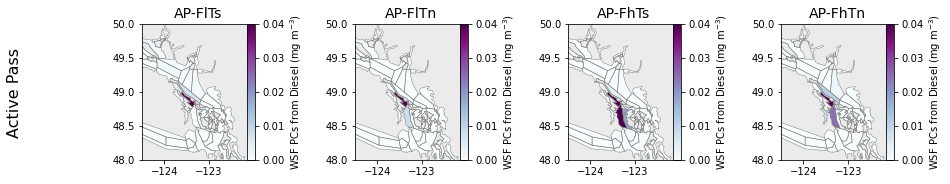

In [9]:
fig = plt.figure(figsize=(14, 6), facecolor='white') #figsize=(9, 12)
gs = plt.GridSpec(1, len(oil_files), wspace=0.5, hspace=0.2, height_ratios=[1],)

for file, oil_path in zip(oil_files, oil_paths):
    date = str(oil_path).split(sep = '_')[3]
    label = 'AP-'+ groups.conditions_with_letters[str(groups.simulations[groups.conditions[date]])]
    position = int(str(groups.simulations[groups.conditions[date]]))-1
    oil_tb = file.variables['TPAH']
    oil_b = oil_tb.mean(axis=0)
    #print(oil_b.max())

    # Add scenario data to Atlantis spatial data
    data_df['TPAH'] = oil_b
    data_df.loc[land_boxes, 'TPAH'] = 0
    oil_df = data_df.loc[data_df['TPAH'] > 0.01] #4% of maximum
    print(label,oil_df.AREA)

    ax = fig.add_subplot(gs[0, position], facecolor = '#EBEBEB') ##C0C0C0
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=-0.5)
    ax = data_df.plot(column = 'TPAH', ax=ax, cax=cax, cmap=cm.BuPu, vmax=0.04, 
    legend_kwds={'label': 'WSF PCs from Diesel (mg m$^{-3}$)'}, legend=True, 
    )
    ax.set_title(label, fontsize = 14) #loc='left'
    ax.set_xlim(-124.5)
    ax.set_ylim(48, 50)
    data_df.boundary.plot(ax=ax, color='grey', linewidths=0.5)
    land_df.plot(ax=ax, color='#EBEBEB')
    #oil_df.plot(ax=ax, color='red',linewidths=0.5)
fig.supylabel('Active Pass', fontsize = 16); #color=hex_colour
#fig.savefig("Figures/spill-map-AP.png", dpi=300, bbox_inches='tight')

In [10]:
affected_boxes = [33, 60, 62, 63]

In [11]:
for box in affected_boxes:
    print('Box '+str(box)+' Depth(m) '+str(data_df.BOTZ[box]))

Box 33 Depth(m) 250
Box 60 Depth(m) 50
Box 62 Depth(m) 100
Box 63 Depth(m) 100


/home/rlovindeer/conda_envs/salishsea-tools/lib/python3.9/site-packages/matplotlib/image.py:443: UserWarning: Warning: converting a masked element to nan.
  dv = np.float64(self.norm.vmax) - np.float64(self.norm.vmin)
/home/rlovindeer/conda_envs/salishsea-tools/lib/python3.9/site-packages/matplotlib/image.py:444: UserWarning: Warning: converting a masked element to nan.
  vmid = np.float64(self.norm.vmin) + dv / 2


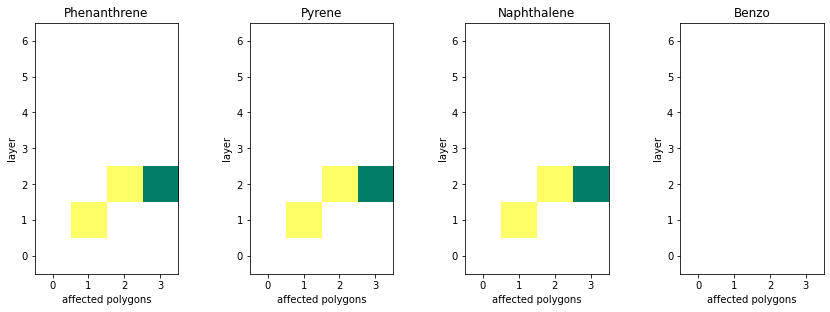

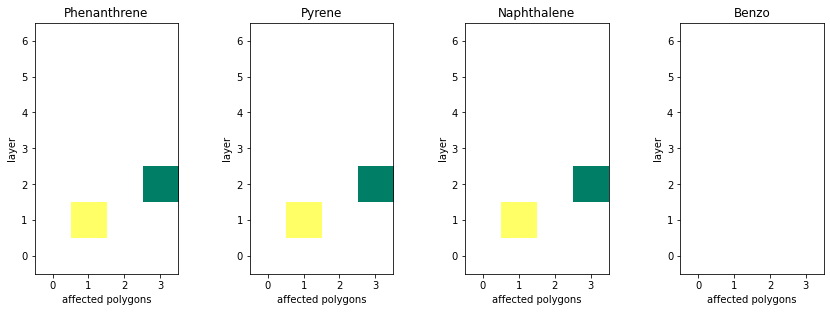

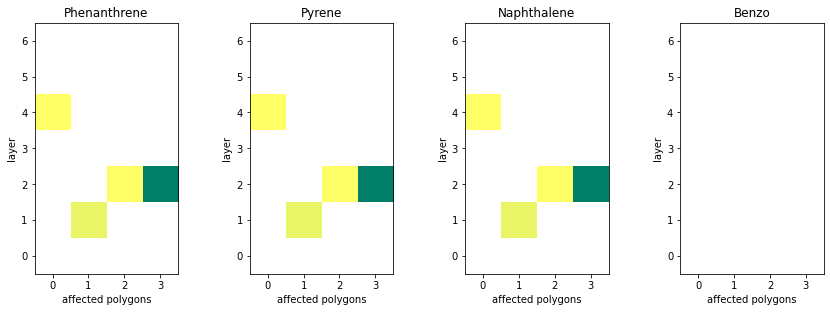

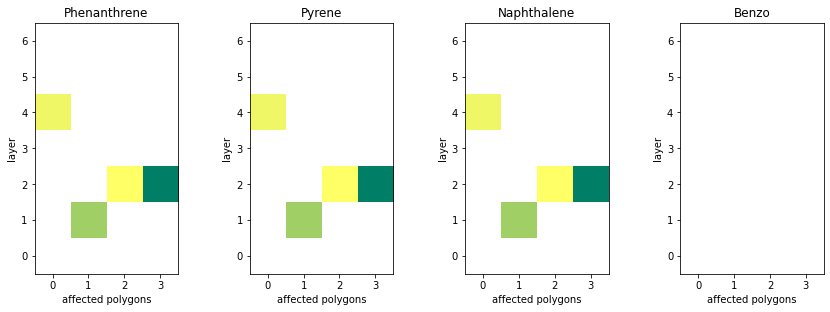

In [12]:
for file in oil_files:
    fig = plt.figure(figsize=(18, 6), facecolor='white') #figsize=(9, 12)
    gs = plt.GridSpec(1, 5, wspace=0.5, hspace=0.2, height_ratios=[1],)
    for pah in groups.pahs:
        ax = fig.add_subplot(gs[0, list(groups.pahs).index(pah)])
        contam_bl = file.variables[str(pah)][8][affected_boxes][:]
        contam = contam_bl.transpose()
        ax.imshow(contam, cmap=cm.summer_r) #copper_r
        ax.invert_yaxis() 
        ax.set_title(str(pah), fontsize = 12)
        ax.set_ylabel('layer')
        ax.set_xlabel('affected polygons')

### Oil injection

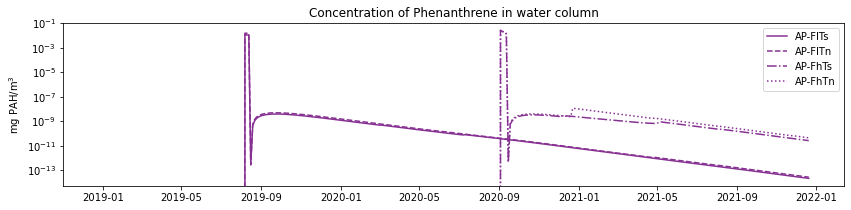

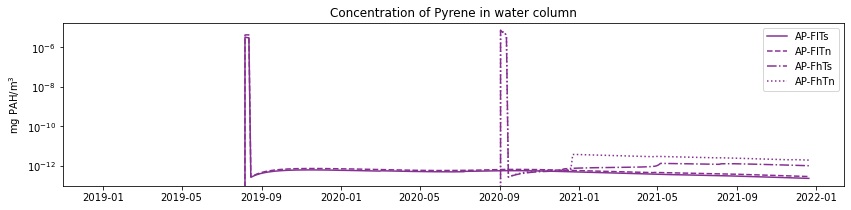

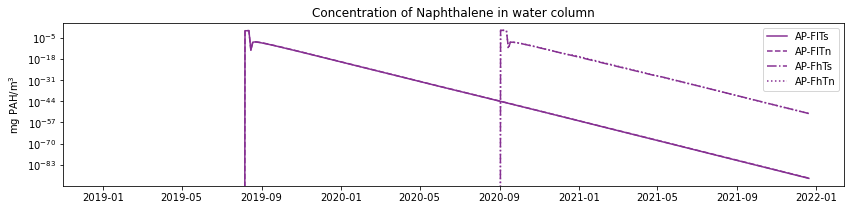

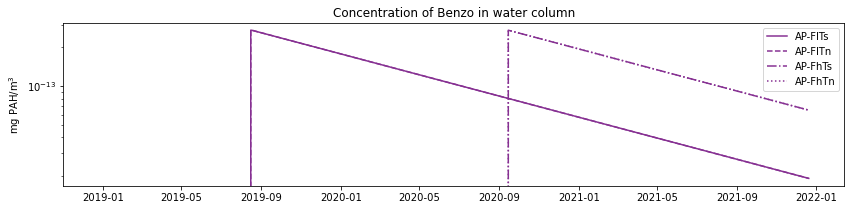

In [13]:
for pah in groups.pahs:
  fig, ax = plt.subplots(figsize = (14,3))
  names = []
  line_styles = itertools.cycle(('-', '--', '-.', ':',(5, (10, 3)),
    (0, (3, 1, 1, 1)),(0, (1, 1)),(0, (3, 10, 1, 10, 1, 10))))
  for scenario, path, i in zip(scenario_datasets,scenario_paths,range(0,len(scenario_datasets))):
      nm = path.parent.stem.split(sep = '_')
      names.append('AP-'+groups.conditions_with_letters[str(nm[2])])
      contam_tbl = scenario.variables[str(pah)][start:end,:,0:6]
      contam_tb = contam_tbl.sum(axis=2)
      contam_t = contam_tb.sum(axis=1)
      ax.semilogy(scenario.t[start:end], contam_t, color=hex_colour, linestyle=next(line_styles))
  ax.set_title('Concentration of '+ pah +' in water column', fontsize = 12)
  ax.set_ylabel('mg PAH/m$^3$')
  ax.legend(names, loc='best')